# Part 1: CNN 

**Assignment 03: Convolutional Neural Networks**  

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(0)

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## P1.1 Input Image

The grayscale image is a 6×6 matrix. Each value represents a pixel intensity (0–255 range here used as small integers).

Input Image (6x6):
[[1. 2. 0. 3. 1. 2.]
 [2. 1. 1. 0. 2. 3.]
 [0. 1. 2. 3. 1. 0.]
 [3. 0. 1. 2. 2. 1.]
 [2. 1. 0. 1. 3. 0.]
 [1. 0. 2. 1. 0. 2.]]

Shape: (6, 6)


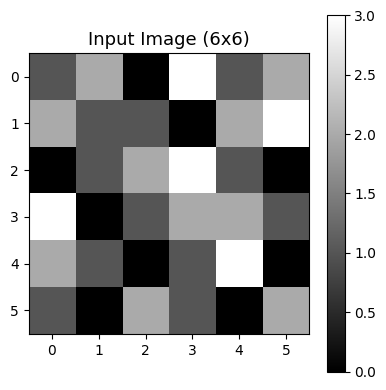

In [9]:
# Define the 6x6 grayscale input image
image = np.array([
    [1, 2, 0, 3, 1, 2],
    [2, 1, 1, 0, 2, 3],
    [0, 1, 2, 3, 1, 0],
    [3, 0, 1, 2, 2, 1],
    [2, 1, 0, 1, 3, 0],
    [1, 0, 2, 1, 0, 2]
], dtype=np.float32)

print("Input Image (6x6):")
print(image)
print(f"\nShape: {image.shape}")

# Visualize the input image
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray', interpolation='nearest')
plt.colorbar()
plt.title('Input Image (6x6)', fontsize=13)
plt.tight_layout()
plt.savefig('p1_input_image.png', dpi=100, bbox_inches='tight')
plt.show()

---
## P1.2 Spatial Dimension Calculation

The output size formula for a convolution or pooling layer is:

$$\text{Output Size} = \left\lfloor \frac{N - F + 2P}{S} \right\rfloor + 1$$

Where:
- **N** = Input spatial size
- **F** = Filter (kernel) size
- **P** = Padding
- **S** = Stride

### Conv Layer 1
- N = 6, F = 3, P = 0, S = 1
- Output = (6 - 3 + 0) / 1 + 1 = **4** → Output shape: **4×4**

### Max Pooling Layer
- N = 4, F = 2, P = 0, S = 2
- Output = (4 - 2 + 0) / 2 + 1 = **2** → Output shape: **2×2**

In [10]:
def output_size(N, F, P, S):
    """Calculate output spatial size using the standard formula."""
    return int((N - F + 2 * P) / S) + 1

# Conv Layer 1
N, F, P, S = 6, 3, 0, 1
out_conv = output_size(N, F, P, S)
print(f"Conv Layer 1:   N={N}, F={F}, P={P}, S={S}")
print(f"  Output size = ({N} - {F} + 2*{P}) / {S} + 1 = {out_conv}x{out_conv}")

# Max Pooling Layer
N2, F2, P2, S2 = out_conv, 2, 0, 2
out_pool = output_size(N2, F2, P2, S2)
print(f"\nMax Pooling:    N={N2}, F={F2}, P={P2}, S={S2}")
print(f"  Output size = ({N2} - {F2} + 2*{P2}) / {S2} + 1 = {out_pool}x{out_pool}")

print(f"\nSummary of Shapes:")
print(f"  Input            : 6x6")
print(f"  After Conv Layer : {out_conv}x{out_conv}")
print(f"  After MaxPool    : {out_pool}x{out_pool}")

Conv Layer 1:   N=6, F=3, P=0, S=1
  Output size = (6 - 3 + 2*0) / 1 + 1 = 4x4

Max Pooling:    N=4, F=2, P=0, S=2
  Output size = (4 - 2 + 2*0) / 2 + 1 = 2x2

Summary of Shapes:
  Input            : 6x6
  After Conv Layer : 4x4
  After MaxPool    : 2x2


---
## P1.3 Convolution Layer Forward Pass

We apply 2 filters manually. Each filter slides over the 6×6 image with stride=1, no padding. At each position we compute the **sum of element-wise products** plus a **bias of 1**.

**Filter 1** (detects vertical edges):
```
[[ 1,  0, -1],
 [ 1,  0, -1],
 [ 1,  0, -1]]
```

**Filter 2** (detects horizontal edges):
```
[[-1,  2, -1],
 [ 0,  0,  0],
 [-1,  2, -1]]
```

Feature Map 1 (Filter 1, before ReLU):
[[ 1. -1.  0.  2.]
 [ 2. -2.  0.  2.]
 [ 3. -3. -2.  6.]
 [ 4. -2. -1.  2.]]

Shape: (4, 4)

Feature Map 2 (Filter 2, before ReLU):
[[ 4. -4.  9. -3.]
 [-4.  2. -1.  3.]
 [ 1. -1.  3.  5.]
 [-6.  4.  2. -1.]]

Shape: (4, 4)


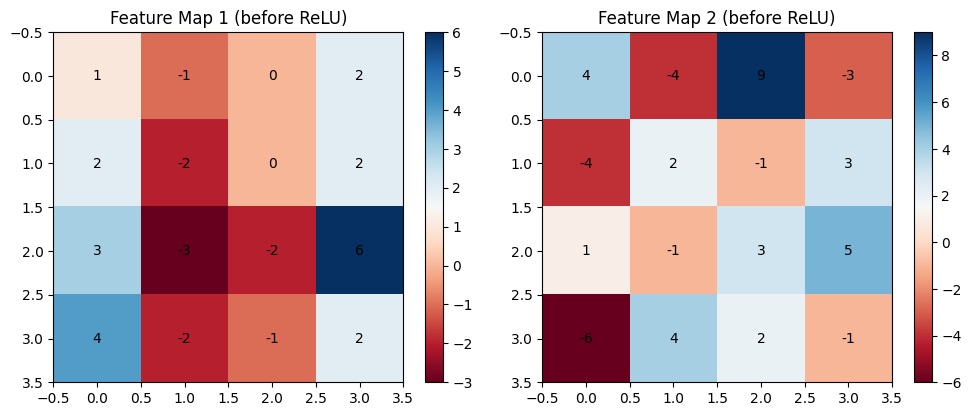

In [11]:
# Define the two 3x3 filters
filter1 = np.array([
    [ 1,  0, -1],
    [ 1,  0, -1],
    [ 1,  0, -1]
], dtype=np.float32)

filter2 = np.array([
    [-1,  2, -1],
    [ 0,  0,  0],
    [-1,  2, -1]
], dtype=np.float32)

bias = 1.0  # same bias for both filters

def manual_conv2d(image, kernel, bias, stride=1):
    """Perform 2D convolution (no padding) manually with NumPy."""
    N = image.shape[0]
    F = kernel.shape[0]
    out_size = (N - F) // stride + 1
    output = np.zeros((out_size, out_size), dtype=np.float32)
    for i in range(out_size):
        for j in range(out_size):
            patch = image[i*stride : i*stride+F, j*stride : j*stride+F]
            output[i, j] = np.sum(patch * kernel) + bias
    return output

# Compute feature maps
feature_map1 = manual_conv2d(image, filter1, bias, stride=1)
feature_map2 = manual_conv2d(image, filter2, bias, stride=1)

print("Feature Map 1 (Filter 1, before ReLU):")
print(feature_map1)
print(f"\nShape: {feature_map1.shape}")

print("\nFeature Map 2 (Filter 2, before ReLU):")
print(feature_map2)
print(f"\nShape: {feature_map2.shape}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im1 = axes[0].imshow(feature_map1, cmap='RdBu', interpolation='nearest')
axes[0].set_title('Feature Map 1 (before ReLU)', fontsize=12)
plt.colorbar(im1, ax=axes[0])
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f'{feature_map1[i,j]:.0f}', ha='center', va='center', fontsize=10)

im2 = axes[1].imshow(feature_map2, cmap='RdBu', interpolation='nearest')
axes[1].set_title('Feature Map 2 (before ReLU)', fontsize=12)
plt.colorbar(im2, ax=axes[1])
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f'{feature_map2[i,j]:.0f}', ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('p1_feature_maps.png', dpi=100, bbox_inches='tight')
plt.show()

---
## P1.4 ReLU Activation

ReLU (Rectified Linear Unit) replaces every negative value with 0:
$$\text{ReLU}(x) = \max(0, x)$$

This introduces non-linearity into the network and helps the model learn complex patterns.

After ReLU — Feature Map 1:
[[1. 0. 0. 2.]
 [2. 0. 0. 2.]
 [3. 0. 0. 6.]
 [4. 0. 0. 2.]]

After ReLU — Feature Map 2:
[[4. 0. 9. 0.]
 [0. 2. 0. 3.]
 [1. 0. 3. 5.]
 [0. 4. 2. 0.]]


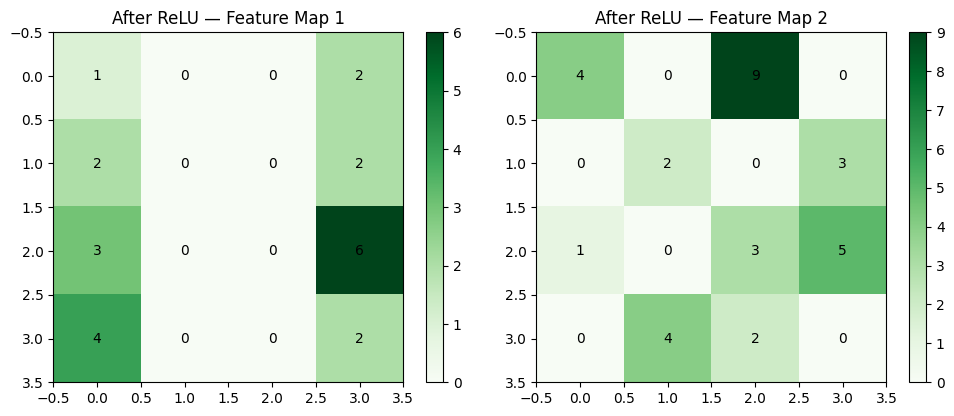

In [12]:
# Apply ReLU: replace negative values with 0
relu1 = np.maximum(0, feature_map1)
relu2 = np.maximum(0, feature_map2)

print("After ReLU — Feature Map 1:")
print(relu1)
print("\nAfter ReLU — Feature Map 2:")
print(relu2)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im1 = axes[0].imshow(relu1, cmap='Greens', interpolation='nearest')
axes[0].set_title('After ReLU — Feature Map 1', fontsize=12)
plt.colorbar(im1, ax=axes[0])
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f'{relu1[i,j]:.0f}', ha='center', va='center', fontsize=10)

im2 = axes[1].imshow(relu2, cmap='Greens', interpolation='nearest')
axes[1].set_title('After ReLU — Feature Map 2', fontsize=12)
plt.colorbar(im2, ax=axes[1])
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f'{relu2[i,j]:.0f}', ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('p1_relu.png', dpi=100, bbox_inches='tight')
plt.show()

---
## P1.5 Max Pooling Layer

Max Pooling selects the **maximum value** from each non-overlapping 2×2 window (stride=2).  
It reduces spatial dimensions, retains the strongest activation, and adds translation invariance.

- Input: 4×4 feature map
- Pool size: 2×2, stride 2
- Output: 2×2 feature map

After Max Pooling — Feature Map 1 (2x2):
[[2. 2.]
 [4. 6.]]

After Max Pooling — Feature Map 2 (2x2):
[[4. 9.]
 [4. 5.]]


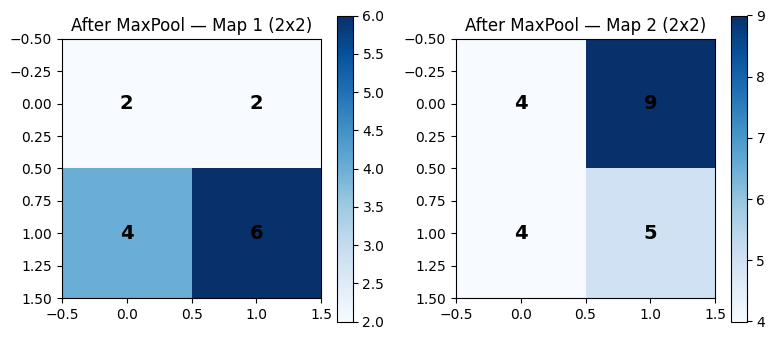

In [13]:
def manual_maxpool2d(feature_map, pool_size=2, stride=2):
    """Perform 2D max pooling manually."""
    N = feature_map.shape[0]
    out_size = (N - pool_size) // stride + 1
    output = np.zeros((out_size, out_size), dtype=np.float32)
    for i in range(out_size):
        for j in range(out_size):
            window = feature_map[i*stride : i*stride+pool_size, j*stride : j*stride+pool_size]
            output[i, j] = np.max(window)
    return output

# Apply max pooling to both ReLU outputs
pool1 = manual_maxpool2d(relu1, pool_size=2, stride=2)
pool2 = manual_maxpool2d(relu2, pool_size=2, stride=2)

print("After Max Pooling — Feature Map 1 (2x2):")
print(pool1)
print("\nAfter Max Pooling — Feature Map 2 (2x2):")
print(pool2)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

im1 = axes[0].imshow(pool1, cmap='Blues', interpolation='nearest')
axes[0].set_title('After MaxPool — Map 1 (2x2)', fontsize=12)
plt.colorbar(im1, ax=axes[0])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{pool1[i,j]:.0f}', ha='center', va='center', fontsize=14, fontweight='bold')

im2 = axes[1].imshow(pool2, cmap='Blues', interpolation='nearest')
axes[1].set_title('After MaxPool — Map 2 (2x2)', fontsize=12)
plt.colorbar(im2, ax=axes[1])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{pool2[i,j]:.0f}', ha='center', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('p1_maxpool.png', dpi=100, bbox_inches='tight')
plt.show()

---
## P1.6 Parameter Calculation

We count all **trainable parameters**: weights + biases in every layer.

### Conv Layer 1:
- 2 filters, each of size 3×3, applied to 1 input channel
- Weights: 2 × (3 × 3 × 1) = **18**
- Biases: 2 × 1 = **2**
- **Subtotal: 20**

### Max Pooling:
- No trainable parameters (just takes the max) → **0**

### Flatten:
- No parameters → **0**

### Linear Layer (FC):
- Input: 2 feature maps × 2×2 = **8** values (flattened)
- Output: **1** neuron
- Weights: 8 × 1 = **8**
- Bias: **1**
- **Subtotal: 9**

### Total: 20 + 9 = **29 trainable parameters**

In [14]:
# ---- Parameter Calculation ----

# Conv Layer 1: 2 filters of 3x3 on 1 channel
num_filters     = 2
filter_h        = 3
filter_w        = 3
in_channels     = 1

conv_weights    = num_filters * filter_h * filter_w * in_channels
conv_biases     = num_filters
conv_params     = conv_weights + conv_biases
print(f"Conv Layer 1:")
print(f"  Weights : {num_filters} x ({filter_h}x{filter_w}x{in_channels}) = {conv_weights}")
print(f"  Biases  : {num_filters}")
print(f"  Subtotal: {conv_params}")

# Max Pooling: no parameters
pool_params = 0
print(f"\nMax Pooling:  {pool_params} parameters")

# Flatten output: 2 maps x 2x2 = 8
flattened_size = num_filters * 2 * 2
print(f"\nFlatten output size: {num_filters} x 2x2 = {flattened_size}")

# Linear Layer: 8 → 1
fc_input  = flattened_size
fc_output = 1
fc_weights = fc_input * fc_output
fc_biases  = fc_output
fc_params  = fc_weights + fc_biases
print(f"\nLinear Layer (FC):")
print(f"  Weights : {fc_input} x {fc_output} = {fc_weights}")
print(f"  Biases  : {fc_biases}")
print(f"  Subtotal: {fc_params}")

total = conv_params + pool_params + fc_params
print(f"TOTAL TRAINABLE PARAMETERS: {total}")


Conv Layer 1:
  Weights : 2 x (3x3x1) = 18
  Biases  : 2
  Subtotal: 20

Max Pooling:  0 parameters

Flatten output size: 2 x 2x2 = 8

Linear Layer (FC):
  Weights : 8 x 1 = 8
  Biases  : 1
  Subtotal: 9
TOTAL TRAINABLE PARAMETERS: 29


---
## P1.7 Summary

| Step | Input Shape | Output Shape | Notes |
|------|------------|--------------|-------|
| Input Image | — | 6×6 | Grayscale |
| Conv Layer 1 (×2 filters) | 6×6 | 4×4 | stride=1, no padding, bias=1 |
| ReLU | 4×4 | 4×4 | Negative → 0 |
| Max Pooling | 4×4 | 2×2 | 2×2 window, stride=2 |
| Flatten | 2×2×2 | 8 | Flatten both maps |
| Linear Layer | 8 | 1 | Single output neuron |

**Total Trainable Parameters: 29**

- Conv: 18 weights + 2 biases = 20
- FC: 8 weights + 1 bias = 9